## Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import joblib

## Data Collection

In [2]:
data=pd.read_csv(r"C:\Users\desai\Downloads\crop_yield\crop_production.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [4]:
data.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [5]:
data.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [6]:
data.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [7]:
data['Production']=data['Production'].fillna(data['Production'].mean())
data

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


In [8]:
z_scores=np.abs(stats.zscore(data['Production']))
df_clean=data[z_scores<3]
df_clean

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


In [9]:
df_clean.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

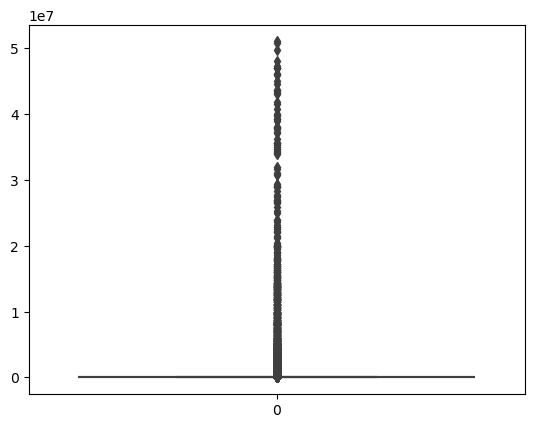

In [10]:
sns.boxplot(df_clean['Production'])
plt.show()

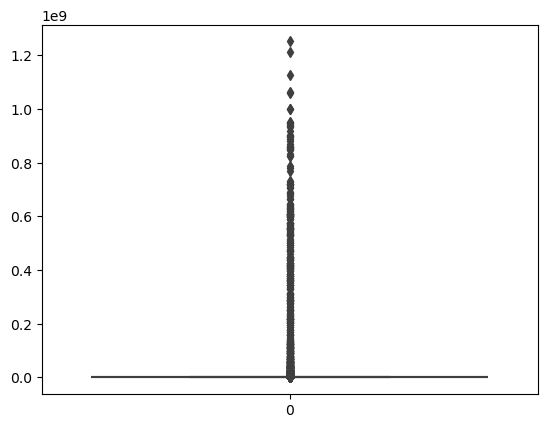

In [11]:
sns.boxplot(data['Production'])
plt.show()

## Exploratory Data Analysis (EDA)

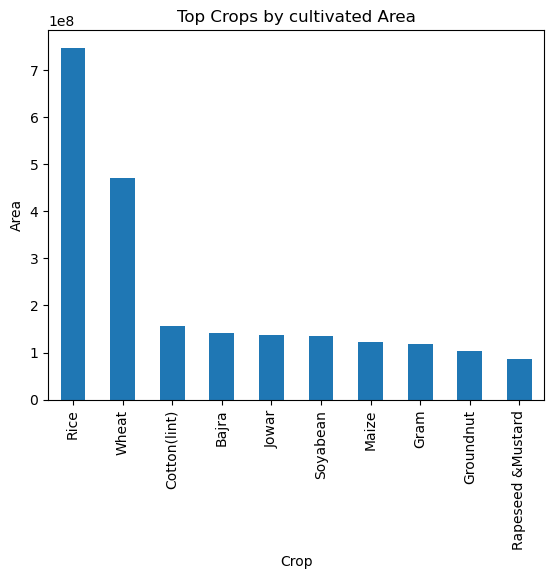

In [12]:
crop_area=df_clean.groupby('Crop')['Area'].sum().sort_values(ascending=False).head(10)
crop_area.plot(kind="bar")
plt.title("Top Crops by cultivated Area")
plt.xlabel("Crop")
plt.ylabel("Area")
plt.show()

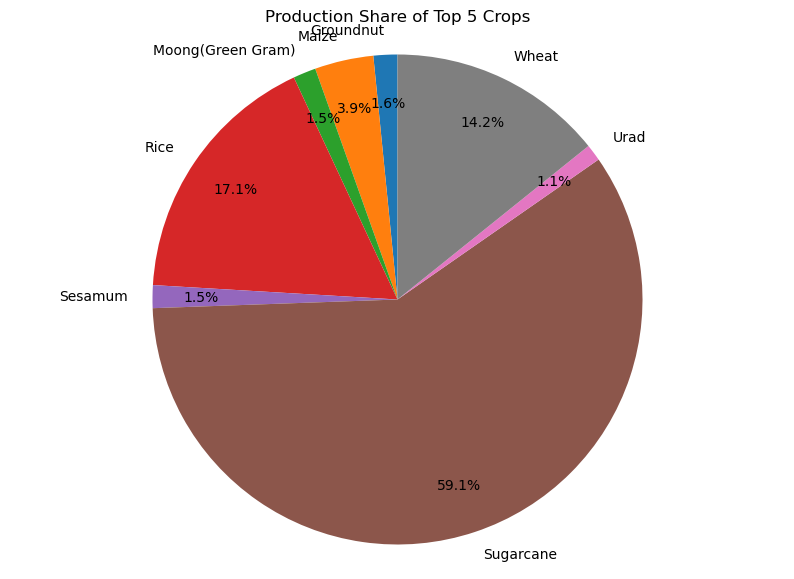

In [13]:
top_crops = df_clean['Crop'].value_counts().head(8).index
filtered_df = df_clean[df_clean['Crop'].isin(top_crops)]

# Group production
crop_prod = filtered_df.groupby('Crop')['Production'].sum()

# Remove zero values (important fix)
crop_prod = crop_prod[crop_prod > 0]

# Plot pie chart
plt.figure(figsize=(10,7))
plt.pie(
    crop_prod,
    labels=crop_prod.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,   # percentage position
    labeldistance=1.1  # label distance
)
plt.title("Production Share of Top 5 Crops")
plt.axis('equal')
plt.show()

C:\Users\desai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\desai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\desai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\desai\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

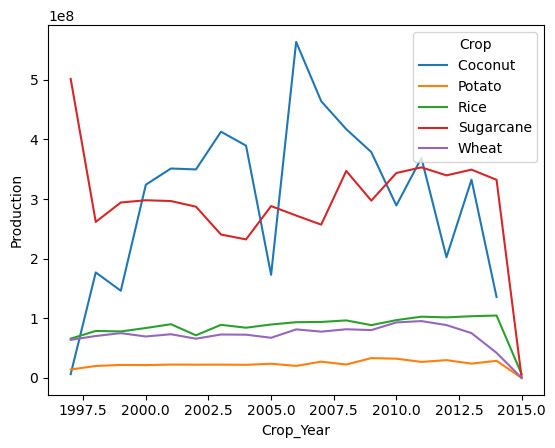

In [14]:
crop_production=df_clean.groupby('Crop')['Production'].sum()
top5_crop_production=crop_production.idxmax()
top5=crop_production.sort_values(ascending=False).head(5).index
data_top5=df_clean[df_clean['Crop'].isin(top5)]
data_grouped=data_top5.groupby(['Crop','Crop_Year'])['Production'].sum().reset_index()
sns.lineplot(data=data_grouped,x='Crop_Year',y='Production',hue='Crop')
plt.show()

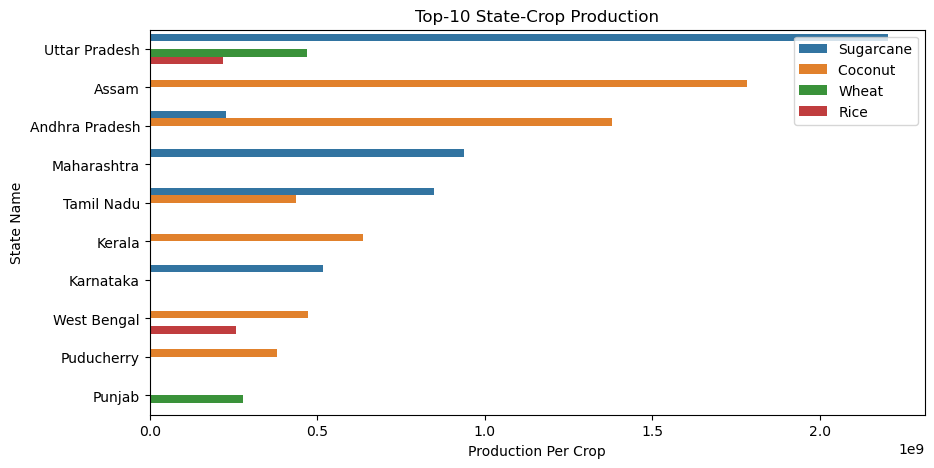

In [15]:
top_state_crop=df_clean.groupby(['State_Name','Crop'])['Production'].sum().nlargest(15).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=top_state_crop,x='Production',y='State_Name',hue='Crop')
plt.title('Top-10 State-Crop Production')
plt.xlabel('Production Per Crop')
plt.ylabel('State Name')
plt.legend(loc='upper right')
plt.show()

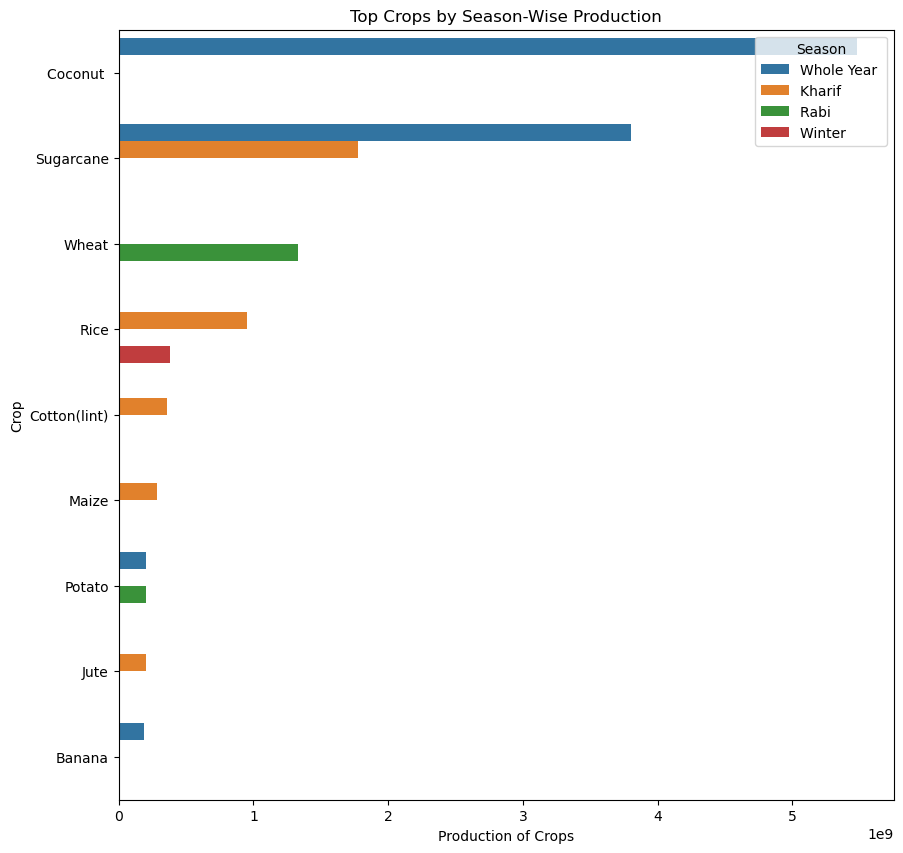

In [16]:
season_crop=df_clean.groupby(['Season','Crop'])['Production'].sum().reset_index()
plt.figure(figsize=(10,10))
sns.barplot(data=season_crop.nlargest(12,'Production'),y='Crop',x='Production',hue='Season')
plt.title('Top Crops by Season-Wise Production')
plt.xlabel('Production of Crops')
plt.ylabel('Crop')
plt.show()

### Data Cleaning

In [17]:
df_clean['Yield']=df_clean['Production']/df_clean['Area']

C:\Users\desai\AppData\Local\Temp\ipykernel_19508\1197633273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Yield']=df_clean['Production']/df_clean['Area']


In [18]:
# Coconut is measured in 'Numbers', not 'Tons'. Including it creates 
# massive outliers that confuse the model.
df_clean = df_clean[~df_clean['Crop'].astype(str).str.contains('Coconut', case=False)]

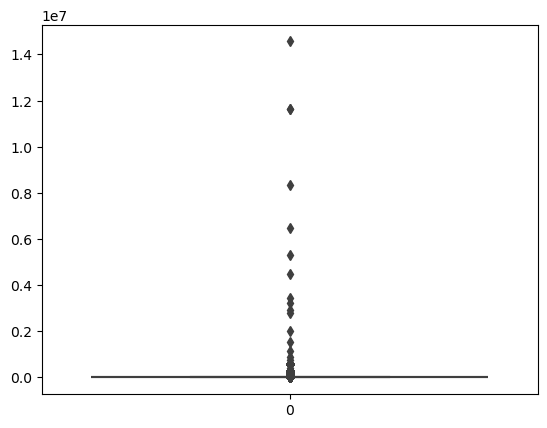

In [19]:
sns.boxplot(df_clean['Yield'])
plt.show()

### Removing Outliers

In [20]:
lower_limit = df_clean['Yield'].quantile(0.05)
upper_limit = df_clean['Yield'].quantile(0.95)

### Feature Engineering & Data Cleaning

In [31]:
##district_yield_lookup = df_clean.groupby('District_Name')['Yield'].mean()
#df_clean['District_Avg_Yield'] = df_clean['District_Name'].map(district_yield_lookup)

In [32]:
district_yield_map = df_clean.groupby('District_Name')['Yield'].mean()
df_clean['District_Avg_Yield'] = df_clean['District_Name'].map(district_yield_map)
df_filtered = df_clean[(df_clean['Yield'] > lower_limit) & (df_clean['Yield'] < upper_limit)]
joblib.dump(district_yield_map, 'district_avg_yield_map.pkl')

C:\Users\desai\AppData\Local\Temp\ipykernel_19508\4221181524.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['District_Avg_Yield'] = df_clean['District_Name'].map(district_yield_map)


['district_avg_yield_map.pkl']

In [33]:
df_filtered['Yield']=df_filtered['Production']/df_filtered['Area']
df_filtered

C:\Users\desai\AppData\Local\Temp\ipykernel_19508\2129259193.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Yield']=df_filtered['Production']/df_filtered['Area']


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,District_Hist_Yield,District_Avg_Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,495.647965,495.647965
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000,495.647965,495.647965
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,495.647965,495.647965
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,495.647965,495.647965
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,495.647965,495.647965
...,...,...,...,...,...,...,...,...,...,...
246085,West Bengal,PURULIA,2014,Summer,Maize,325.0,2039.0,6.273846,471.131093,471.131093
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0,2.617647,471.131093,471.131093
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0,0.738437,471.131093,471.131093
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0,2.141848,471.131093,471.131093


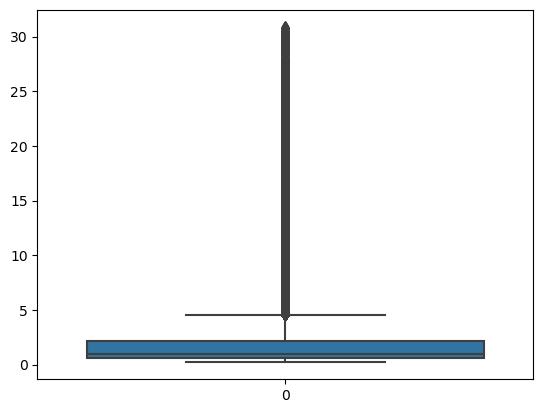

In [34]:
sns.boxplot(df_filtered['Yield'])
plt.show()

### Encoding categorical columns

In [35]:
label_encoders={}
categorical_cols = ['State_Name', 'District_Name', 'Season', 'Crop']

In [36]:
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on the FULL dataset column to ensure it knows every possible name
    df_filtered[col] = le.fit_transform(df_filtered[col])
    # Save the encoder for this specific column
    label_encoders[col] = le

C:\Users\desai\AppData\Local\Temp\ipykernel_19508\2313156486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = le.fit_transform(df_filtered[col])
C:\Users\desai\AppData\Local\Temp\ipykernel_19508\2313156486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = le.fit_transform(df_filtered[col])
C:\Users\desai\AppData\Local\Temp\ipykernel_19508\2313156486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [37]:
joblib.dump(label_encoders, 'all_label_encoders.pkl')

['all_label_encoders.pkl']

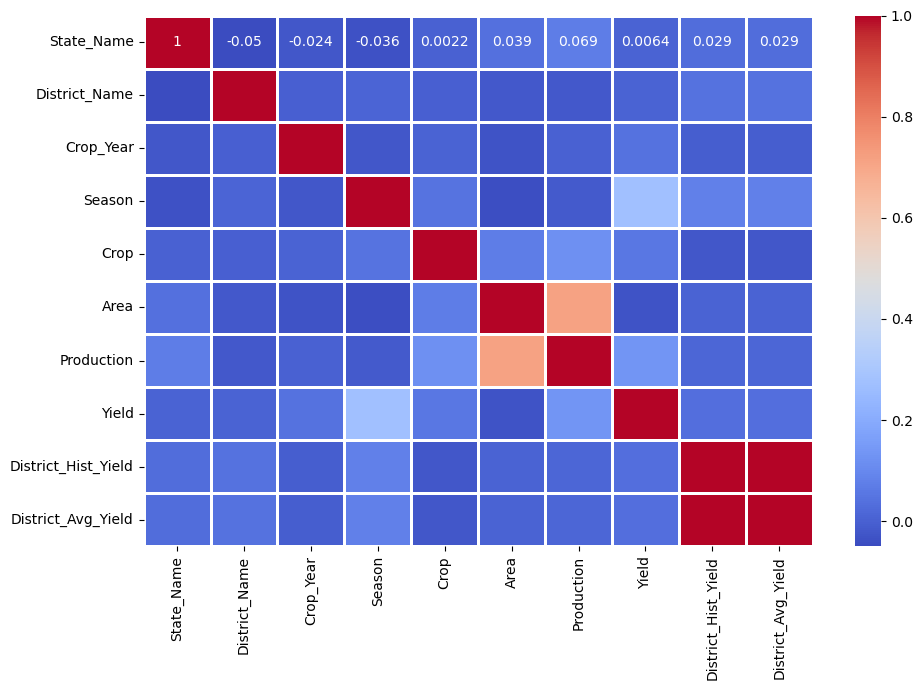

In [38]:
plt.figure(figsize=(10,7))
corr_matrix=df_filtered.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidth=0.8)
plt.tight_layout()
plt.show()

### Feature Selection

In [40]:
features = ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area','District_Avg_Yield']
X=df_filtered[features]
Y=df_filtered['Yield']

In [41]:
X

,State_Name,District_Name,Crop_Year,Season,Crop,Area,District_Avg_Yield
0,0,427,2000,1,1,1254.0,495.647965
1,0,427,2000,1,64,2.0,495.647965
2,0,427,2000,1,79,102.0,495.647965
3,0,427,2000,4,5,176.0,495.647965
4,0,427,2000,4,18,720.0,495.647965
...,...,...,...,...,...,...,...
246085,32,471,2014,3,51,325.0,471.131093
246086,32,471,2014,3,79,306.0,471.131093
246087,32,471,2014,3,86,627.0,471.131093
246089,32,471,2014,5,79,279151.0,471.131093


In [42]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
random_model=RandomForestRegressor(n_estimators=100,random_state=42,max_depth=15)
random_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=15, random_state=42)

In [43]:
y_pred=random_model.predict(x_test)

In [44]:
print("Random Forest Model Evaluation")
print(f"R² Score: {r2_score(y_test,y_pred)}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Accuracy:{r2_score(y_test, y_pred)*100:.1f}%")

Random Forest Model Evaluation
R² Score: 0.9196702701132518
RMSE:1.22
MAE: 0.51
Accuracy:92.0%


In [45]:
xg_model = XGBRegressor(n_estimators=200, max_depth=8, random_state=42,learning_rate=0.1,n_jobs=-1)
xg_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [46]:
y_pred_xg=xg_model.predict(x_test)
print("XGB Regression Model Evaluation")
print(f"R² Score: {r2_score(y_test,y_pred_xg)}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_xg)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xg):.2f}")
print(f"Accuracy:{r2_score(y_test, y_pred_xg)*100:.1f}%")

XGB Regression Model Evaluation
R² Score: 0.9100131436010709
RMSE:1.29
MAE: 0.59
Accuracy:91.0%


In [47]:
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

In [48]:
y_pred_linear=linear_model.predict(x_test)
print("Linear Model Evaluation")
print(f"R² Score: {r2_score(y_test,y_pred_linear)}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_linear)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear):.2f}")
print(f"Accuracy:{r2_score(y_test, y_pred_linear)*100:.1f}%")

Linear Model Evaluation
R² Score: 0.07911834295380182
RMSE:4.13
MAE: 2.36
Accuracy:7.9%


In [49]:
joblib.dump(random_model, 'crop_yield_random_model.pkl')

['crop_yield_random_model.pkl']

In [50]:
joblib.dump(xg_model,'crop_yield_xg_model.pkl')

['crop_yield_xg_model.pkl']

In [ ]:
#joblib.dump(label_encode_model, 'label_encoder.pkl')

In [ ]:
#grid_search_model.fit(x_train,y_train)

In [51]:
param_grid=param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    #'min_samples_split': [2, 5]
}

In [57]:
random_search = RandomizedSearchCV(
    estimator=random_model, 
    param_distributions=param_grid, 
    n_iter=10,    # Only try 10 combinations
    cv=3,         # Lower folds for speed
    n_jobs=-1, 
    random_state=42
)

In [58]:
random_search.fit(x_train,y_train)

C:\Users\desai\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(max_depth=15,
                                                   random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'n_estimators': [50, 100]},
                   random_state=42)

In [59]:
y_pred_random_search=random_search.predict(x_test)

In [60]:
r2 = r2_score(y_test, y_pred_random_search)
mae = mean_absolute_error(y_test, y_pred_random_search)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_random_search))

In [61]:
print(f"--- Performance Metrics (Best Sample Model) ---")
print(f"R2 Score (Accuracy): {r2:.4f}") # 1.0 is perfect
print(f"Mean Absolute Error: {mae:.4f}")  # Lower is better
print(f"Root Mean Squared Error: {rmse:.4f}") # Lower is better
print(f"Model Accuracy (R2 %): {r2 * 100:.1f}%")

--- Performance Metrics (Best Sample Model) ---
R2 Score (Accuracy): 0.9314
Mean Absolute Error: 0.3969
Root Mean Squared Error: 1.1276
Model Accuracy (R2 %): 93.1%


In [62]:
best_model = random_search.best_estimator_
y_pred_final = best_model.predict(x_test)

In [63]:
final_r2 = r2_score(y_test, y_pred_final)
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Final Model Accuracy (R2): {final_r2 * 100:.2f}%")

Best Parameters Found: {'n_estimators': 100, 'max_depth': None}
Final Model Accuracy (R2): 93.14%


In [64]:
joblib.dump(best_model, 'crop_yield_random_search_cv_model.pkl')

['crop_yield_random_search_cv_model.pkl']

In [65]:
model=joblib.load('crop_yield_random_search_cv_model.pkl')
encoder=joblib.load('all_label_encoders.pkl')

In [66]:
district_yield_lookup = joblib.load('district_avg_yield_map.pkl') 

def predict_crop_yield():
    print("------ Crop Yield Prediction System --------")
    
    # 2. Collect basic user inputs
    state = input("Enter state name: ").strip().title()
    district = input("Enter district name: ").strip().upper()
    
    try:
        year = int(input("Enter year (e.g., 2024): "))
    except ValueError:
        print("Error: Please enter a valid number for the year.")
        return
        
    # Handling your specific Season padding (.ljust)
    season = input("Enter season (eg: Kharif): ").strip().title().ljust(11)
    crop = input("Enter crop type (eg: Wheat): ").strip().title()
    
    try:
        area = float(input("Enter Area (in Hectares): "))
    except ValueError:
        print("Error: Please enter a valid number for the area.")
        return

    # 3. AUTOMATIC LOOKUP for District_Avg_Yield
    # This prevents the user from having to guess the average yield
    if district in district_yield_lookup:
        dist_avg = district_yield_lookup[district]
    else:
        # Fallback to a general average if the district is new/unseen
        dist_avg = district_yield_lookup.mean()

    # 4. Create DataFrame with your 7 features in the EXACT order
    user_data = pd.DataFrame([[
        state, district, year, season, crop, area, dist_avg
    ]], columns=['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'District_Avg_Yield'])

    # 5. Transform categorical variables to numbers
    try:
        user_data['State_Name'] = encoder['State_Name'].transform([state])[0]
        user_data['District_Name'] = encoder['District_Name'].transform([district])[0]
        user_data['Season'] = encoder['Season'].transform([season])[0]
        user_data['Crop'] = encoder['Crop'].transform([crop])[0]
    except KeyError as e:
        print(f"Error: {e} not found in training data. Check spelling/casing.")
        return

    # 6. Make prediction
    prediction = model.predict(user_data)
    
    print(f"\nPredicted Yield: {prediction[0]:.2f} tons per hectare")
    print(f"Estimated Total Production: {prediction[0] * area:.2f} tons")

# Run the system
predict_crop_yield()

------ Crop Yield Prediction System --------


Enter state name:  uttar pradesh
Enter district name:  lucknow
Enter year (e.g., 2024):  2026
Enter season (eg: Kharif):  kharif
Enter crop type (eg: Wheat):  wheat
Enter Area (in Hectares):  4589.0



Predicted Yield: 1.89 tons per hectare
Estimated Total Production: 8672.70 tons
